In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df = pd.read_csv('/Users/d.mkhlnk/Downloads/test_d.csv', sep=',', encoding='utf8')

In [6]:
df.head()

,Id,1. Существенное,1. Направление,body_text_clust_3,filtered_text
0,S_15,1,1.0,"['оказывать', 'эмитент', 'стоимость', 'котиров...",оказывать стоимость котировка сократить резуль...
1,S_16,0,NaN,"['проведение', 'заседание', 'наблюдательный', ...",проведение заседание наблюдательный совет пове...
2,S_23,1,1.0,"['досрочный', 'погашение', 'облигация', 'эмите...",досрочный погашение облигация облигация которы...
3,S_27,0,NaN,"['досрочный', 'погашение', 'облигация', 'эмите...",досрочный погашение облигация облигация которы...
4,S_30,0,NaN,"['отдельный', 'решение', 'принять', 'наблюдате...",отдельный решение принять наблюдательный совет...


In [58]:
df['1. Направление'].fillna(0, inplace=True)
abs_values

1. Существенное
0    842
1    158
Name: count, dtype: int64

Text(0, 0.5, ' ')

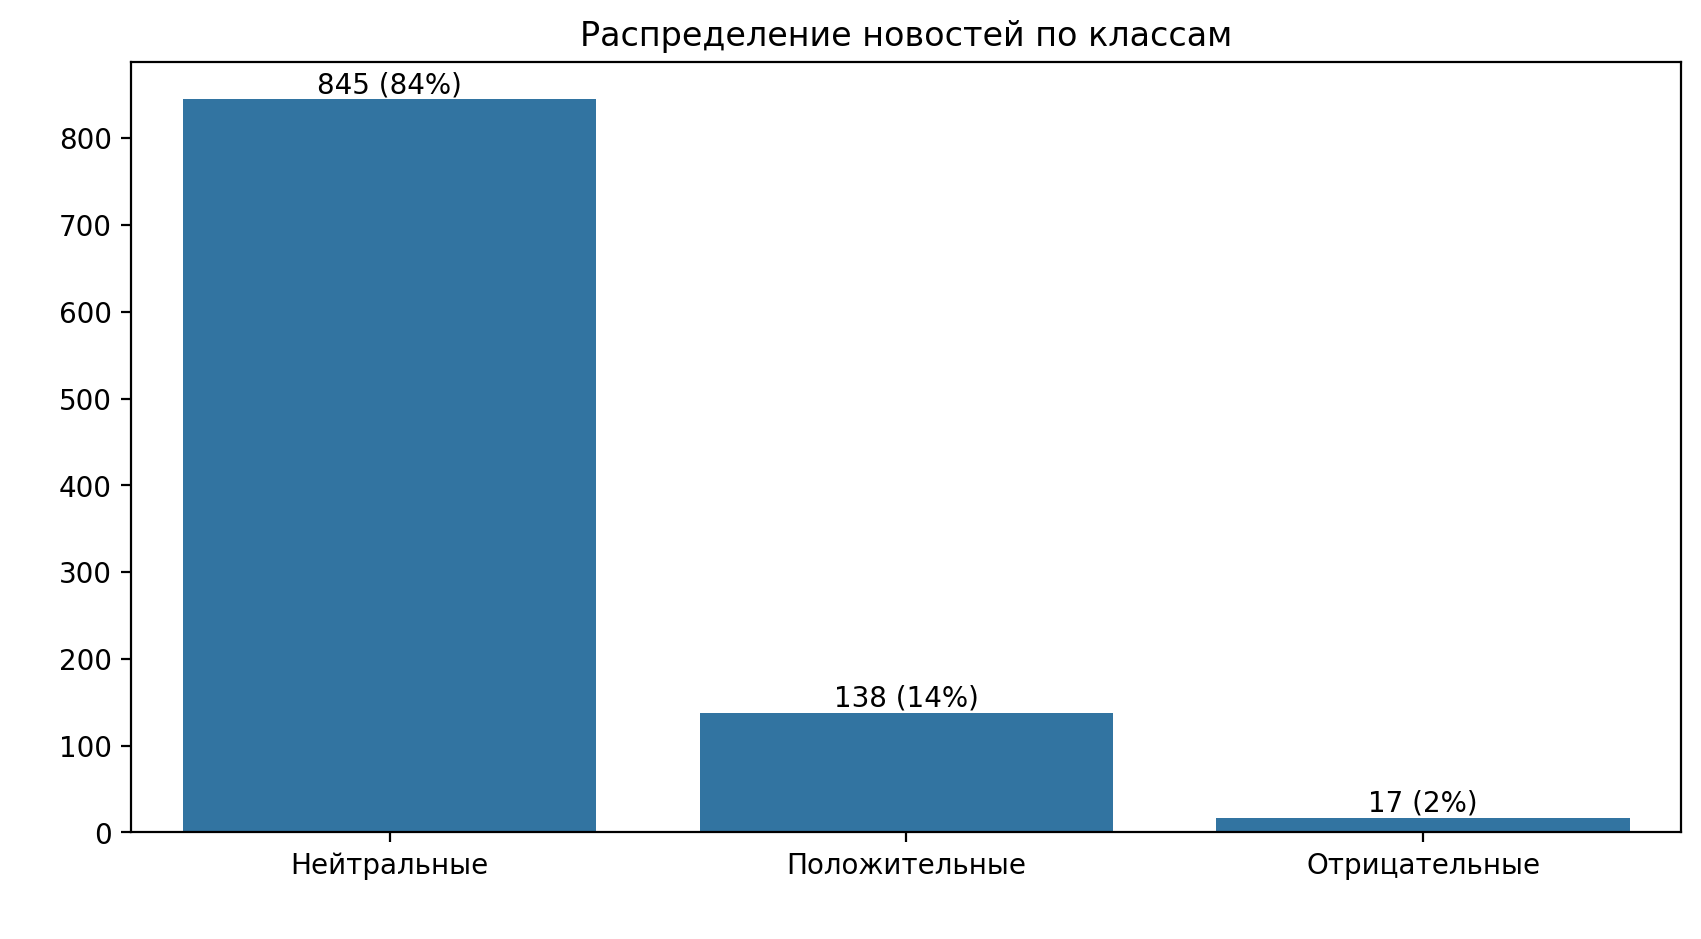

In [66]:
# Function to add value labels on top of bars
plt.figure(figsize=(10, 5), dpi = 200 )
ax = sns.countplot(x=df['1. Направление'],
                   order=df['1. Направление'].value_counts(ascending=False).index);
        
abs_values = df['1. Направление'].value_counts(ascending=False)
rel_values = df['1. Направление'].value_counts(ascending=False, normalize=True).values * 100
lbls = [f'{p[0]} ({p[1]:.0f}%)' for p in zip(abs_values, rel_values)]

ax.bar_label(container=ax.containers[0], labels=lbls)
plt.title('Распределение новостей по классам')
plt.xticks([0,1,2], ['Нейтральные', 'Положительные', 'Отрицательные'])
plt.xlabel(' ')
plt.ylabel(' ')



In [32]:
df['1. Направление'].value_counts()

1. Направление
 0.0    845
 1.0    138
-1.0     17
Name: count, dtype: int64

In [122]:
X = df['filtered_text']
y = df['1. Направление']
print(y)


0      1.0
1      0.0
2      1.0
3      0.0
4      0.0
      ... 
995    0.0
996    1.0
997    0.0
998   -1.0
999    0.0
Name: 1. Направление, Length: 1000, dtype: float64


In [124]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


In [253]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=101)
tfidf = TfidfVectorizer()
X_train_vectorized = tfidf.fit_transform(X_train)
X_test_vectorized = tfidf.transform(X_test)


In [255]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train_vectorized,y_train)


MultinomialNB()

In [257]:
y_pred = nb.predict(X_test_vectorized)

In [259]:
## Оценка работы модели 

In [261]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay

In [263]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.00      0.00      0.00         2
         0.0       0.86      0.99      0.92       166
         1.0       0.88      0.22      0.35        32

    accuracy                           0.86       200
   macro avg       0.58      0.40      0.42       200
weighted avg       0.85      0.86      0.82       200



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


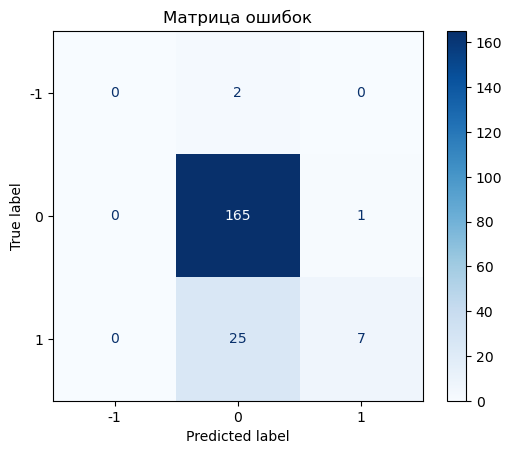

In [265]:
# Создаем матрицу ошибок
cm = confusion_matrix(y_test, y_pred)

# Визуализируем
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 0, 1])
disp.plot(cmap='Blues')  
plt.title("Матрица ошибок")
plt.show()

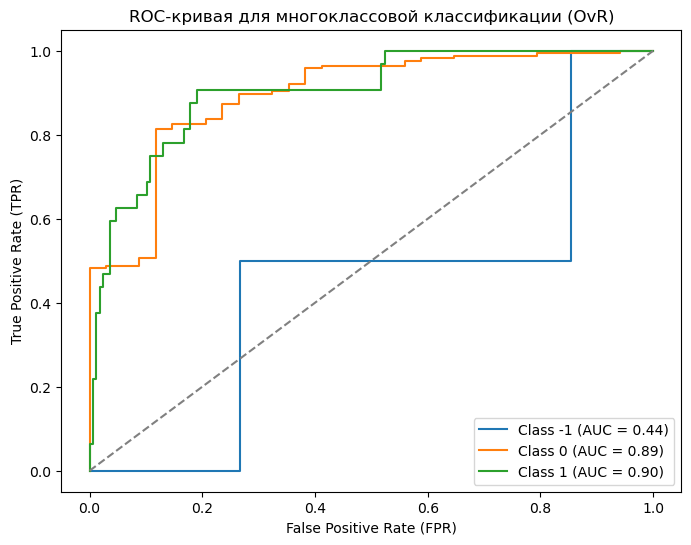

In [267]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Бинаризуем классы (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[-1, 0, 1])
y_pred_prob = nb.predict_proba(X_test_vectorized)  # Получаем вероятности

# Построим ROC-кривые для каждого класса
plt.figure(figsize=(8, 6))
for i, label in enumerate([-1, 0, 1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {label} (AUC = {roc_auc:.2f})')

# Линия случайного классификатора
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Оформление графика
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC-кривая для многоклассовой классификации (OvR)")
plt.legend()
plt.show()

In [271]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression(max_iter=1000)
log.fit(X_train_vectorized,y_train)


LogisticRegression(max_iter=1000)

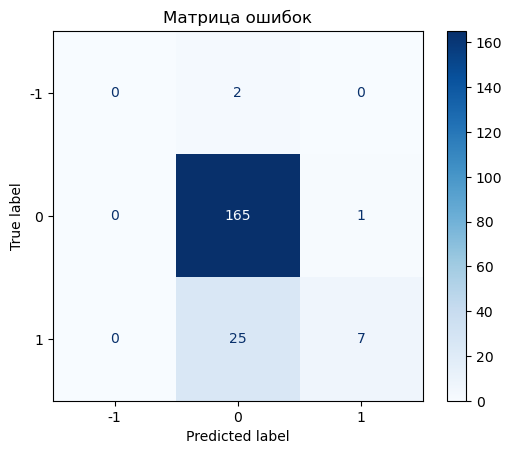

In [273]:
def report(model):
    preds = model.predict(X_test_vectorized)
    print(classification_report(y_test,preds))
    # plot_confusion_matrix(model, X_test_vectorized,y_test)
    
cm = confusion_matrix(y_test, y_pred)

# Визуализируем
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 0, 1])
disp.plot(cmap='Blues')  
plt.title("Матрица ошибок")
plt.show()


              precision    recall  f1-score   support

        -1.0       0.00      0.00      0.00         2
         0.0       0.86      0.99      0.92       166
         1.0       0.88      0.22      0.35        32

    accuracy                           0.86       200
   macro avg       0.58      0.40      0.42       200
weighted avg       0.85      0.86      0.82       200



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


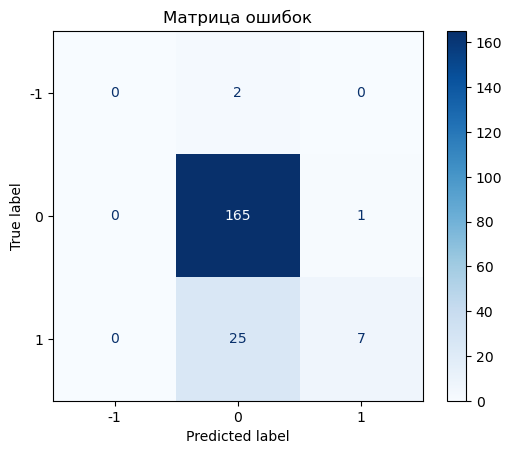

In [243]:
report(nb)

In [275]:
report(log)

              precision    recall  f1-score   support

        -1.0       0.00      0.00      0.00         2
         0.0       0.89      0.99      0.94       166
         1.0       0.87      0.41      0.55        32

    accuracy                           0.89       200
   macro avg       0.59      0.47      0.50       200
weighted avg       0.88      0.89      0.87       200



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
